In [20]:
using LinearAlgebra
using Plots
gr()
Plots.GRBackend()
filename = ""

include("Optimisation.jl")
include("Parameterization.jl")
include("RaySolver.jl")
include("PlotRays.jl")

#Palette de couleurs pour les rayons
colors = [:red, :orange, :lightgreen, :black, :blue, :purple, :grey]
palette = palette(:viridis, 10)
#Mettre un colortheme

7-element Vector{Symbol}:
 :red
 :orange
 :lightgreen
 :black
 :blue
 :purple
 :grey

Définition des paramètres de contrôle

In [21]:
controlx = [-1.5 -1.2 -0.7 -0.3 0. 0.3 0.7 1. 1.5]
controly = [0. 0.1 0.3 0.3 0. 0.3 0.3 0.1 0.] .+ 1.
control = vcat(controlx, controly)
control0 = control

2×9 Matrix{Float64}:
 -1.5  -1.2  -0.7  -0.3  0.0  0.3  0.7  1.0  1.5
  1.0   1.1   1.3   1.3  1.0  1.3  1.3  1.1  1.0

In [22]:
fixedcontrolpoint = [0.,1.]

2-element Vector{Float64}:
 0.0
 1.0

In [23]:
#Fonction coût écart à un point
# Jeu de rayons parallèles en entrée
Nray= 50
Nangle = 7
FOV = 10 # en degrés
FOV = FOV * pi / 180.
angles = [pi / 2. - FOV + 2 * FOV * k / Nangle for k in 1:Nangle]
#sources = (Ray(-1. + 2 * i / Nray, angle  ) for i in 0:Nray)  


7-element Vector{Float64}:
 1.4461299516524444
 1.4959965017094252
 1.545863051766406
 1.5957296018233869
 1.645596151880368
 1.6954627019373487
 1.7453292519943295

Rayons en entrée du système avant optimisation

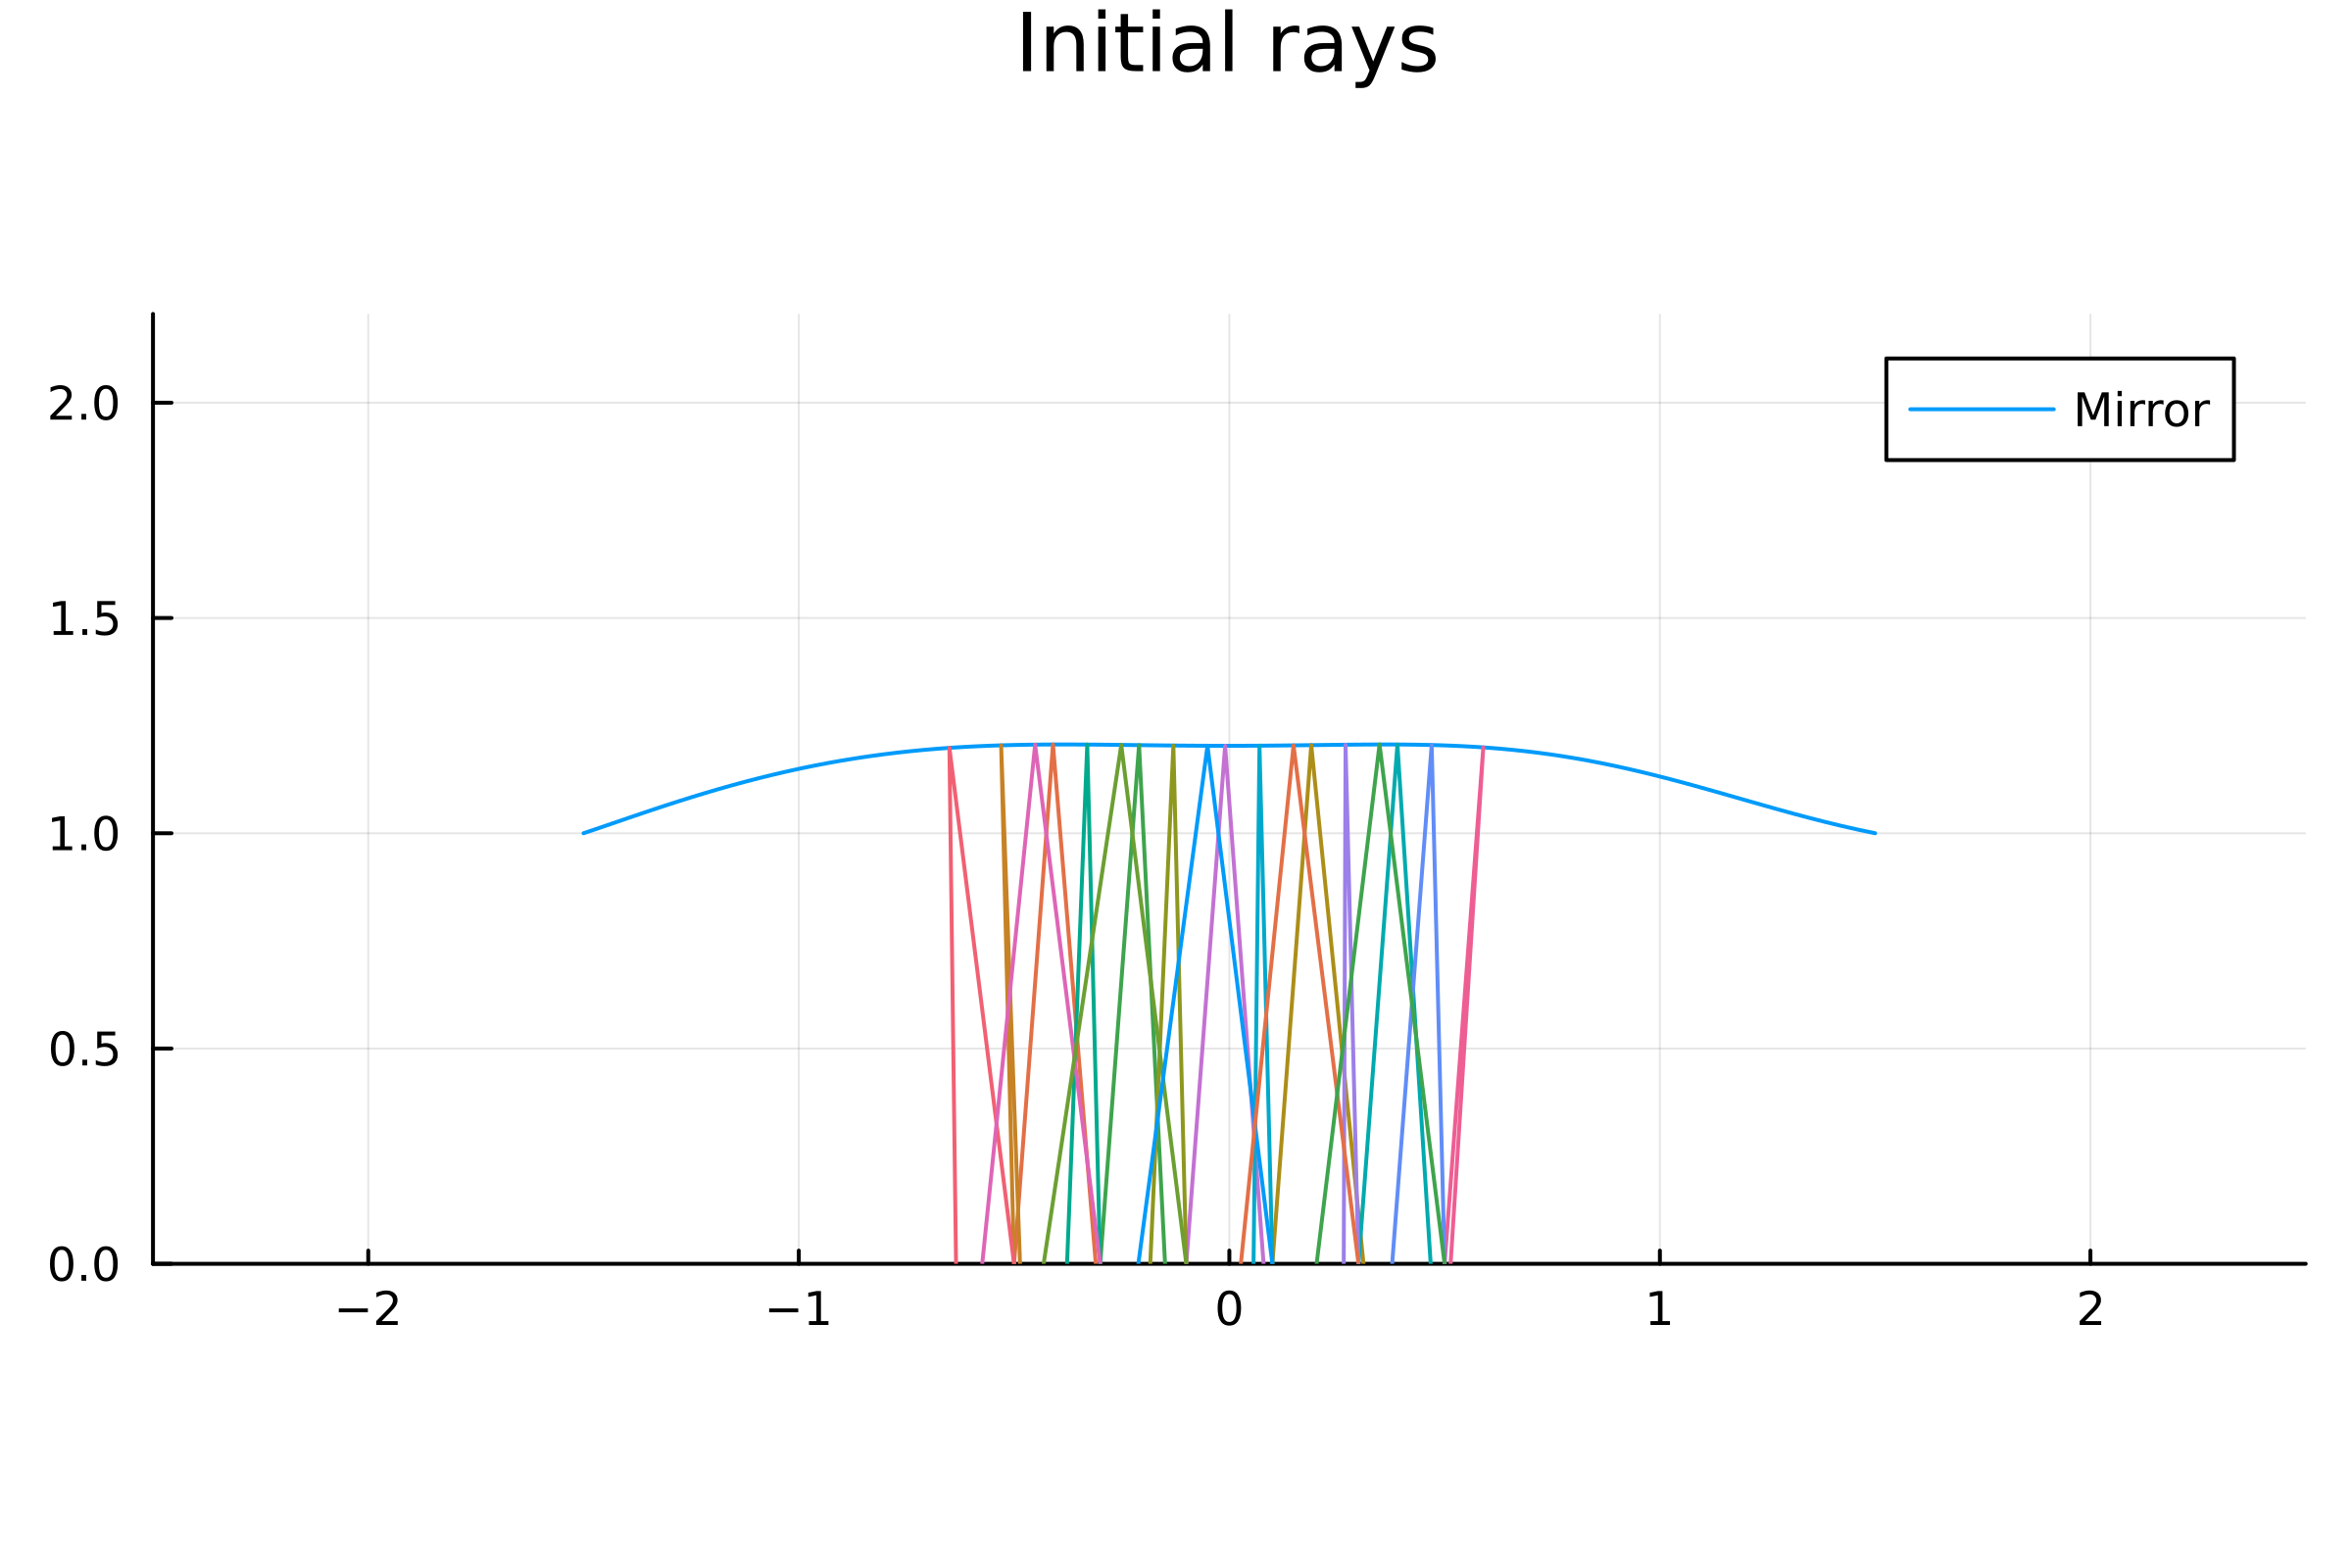

In [24]:
points = bezier(control, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( - maximum( -1. .*points[2,:] ) -1. , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Mirror", title = "Initial rays", dpi = 400)
for (k,angle) in enumerate(angles)
    if k%2 == 0
        source4plot = (Ray([-0.5 + i / 5, 0.], angle  ) for i in 0:5)  
        for ray in source4plot
            plot!(ray)
            #plot!(ray, colors[k-1])
        end
    end
end
savefig("init_rays_focal.png")
display(plt)

$$
j(\beta) = \mathbb{E}[ | [X_F]_1 - f[\Xi_S]_1|^2] = \frac{1}{N_{ray}} \sum_{i=1}^{N_{ray}} ( x_i(\beta) - f\cos(\theta_i))^2
$$

In [26]:
#Fonction coût
focal = bezier(control,0.5)[2] 
function cost0(control::Matrix{Float64})::Float64
    s = 0.
    for angle in angles
        source = (Ray([-0.5 + i / Nray, 0.], angle  ) for i in 0:Nray)  
        for ray in source
            s+= ( projectionplanfocal(billiard(control,ray) ).pos[1] - focal * cos(angle))^2.
        end
    end
    return s/ (Nray * Nangle)
end
cost0(control)
focal

1.203125

Définition du coût

In [498]:
# Differentiel en x de la foinction cout sur le plan focal
function diffj0x(ray::Ray, cosangle::Float64)::Vector{Float64}
    return 2. * [ray.pos[1] - focal * cosangle, 0.]
end

# Differentiel en xi de la foinction cout sur le plan focal
function diffj0xi(ray::Ray)::Vector{Float64}
    return [0., 0.]
end

# Differentiel en x de la foinction cout sur le miroir
function jtildex(ray::Ray, cosangle::Float64)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalx(ray, diffj0x(rayf,cosangle), diffj0xi(rayf))
end

# Differentiel en xi de la foinction cout sur le miroir
function jtildexi(ray::Ray,cosangle::Float64)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalxi(ray, diffj0x(rayf,cosangle), diffj0xi(rayf))
end



jtildexi (generic function with 2 methods)

In [499]:
function cross2d(vec1::Vector{Float64}, vec2::Vector{Float64})::Real
    return vec1[1]* vec2[2] - vec1[2]* vec2[1] 
end
cross2d([0.,1.], [1.,0.])

-1.0

Définition du gradient

In [500]:
#### fusionner jtilde
### fusionner projection focal (matrice par bloc ? utiliser strcture de julia)
function gradientj0(control::Matrix{Float64})::Matrix{Float64}
    n::Int64 = size(control)[2] - 1  # Degree of the Béziers curve  
    gradient::Matrix{Float64} = zeros(2,n+1)
    for angle in angles
        source = (Ray([-0.5 + i / Nray, 0.], angle  ) for i in 0:Nray) 
        for ray in source
            # on projette sur le miroir et on récupère le $t$ de param
            t::Float64 = intersectionLine(control, ray) 
            dic = geometricquantities(control, t)
            theta = ray.angle
            #prendre un dangle et une normale sortante et renvoie l'angle correspondant au rayon réfléchi
            sdot = dic["normal"][1] * cos(theta) + dic["normal"][2] * sin(theta)
            thetaf = atan( sin(theta) - 2. * sdot * dic["normal"][2], cos(theta) - 2. * sdot * dic["normal"][1] )
            #on calcule les termes de la dérivée de formes
            sderterm = shapederivativeterms(control, t) #termes de la dérivée de formes
            rayr = Ray(dic["point"], thetaf)
            djx = jtildex(rayr,cos(angle))
            djxi = jtildexi(rayr,cos(angle))
            gradient += dot(dic["normal"], djx ) .*  sderterm["thetan"]
            gradient +=  ( sderterm["thetanprime"] * cross2d(dic["normal"], dic["utangent"]) .-  sderterm["thetan"] .* (dic["curvature"] * cross2d(dic["normal"], [cos(thetaf), sin(thetaf)]) / dot([cos(thetaf), sin(thetaf) ], dic["normal"])   ) ) * cross2d(djxi, [cos(thetaf), sin(thetaf)])
        end
    end
    return 2. * gradient ./ (Nray * Nangle)
end


#elle modifie la fonction initiale. Il faudrait mettre un !
function projection(control::Matrix{Float64})::Matrix{Float64}
    n::Int64 = size(control)[2]
    control[: , div(n+1,2)] = fixedcontrolpoint
    return control
end

    

projection (generic function with 1 method)

Test du gradient contre des différences finies

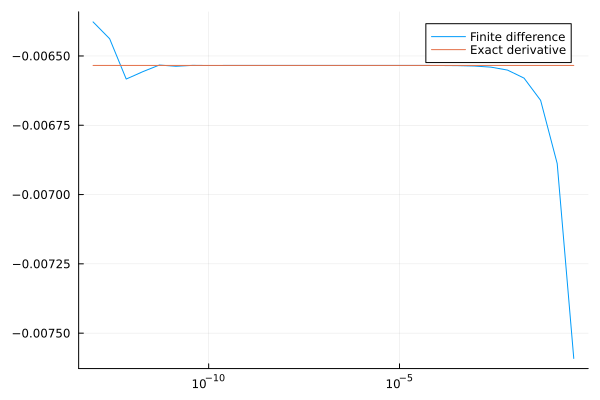

In [501]:
n::Int64 = size(control)[2]
dir = zeros(2,n)
posx = 1
posy = 1
dir[posx,posy] = 1.
#dir = vcat(zeros(1,n),ones(1,n))
dir
N = 30
residu = zeros(2,N)
for k in 1:N
    residu[1,k] = ( cost0(control + exp(-k) .* dir ) - cost0(control) ) / exp(-k)
    residu[2,k] = dot(gradientj0(control), dir)
end
absX =[ k for k in 1:N]
absX =[ exp(-k) for k in 1:N]
#plt = plot(absX,residu[1,:],label= "Différence finie")
#plot!(absX,residu[2,:],label= "Gradient")

plt = plot(absX,residu[1,:],label= "Finite difference", xaxis=:log)
plot!(absX,residu[2,:],label= "Exact derivative")
display(plt)

In [1]:
iter=Vector{Float64}(undef, 0)
cost=Vector{Float64}(undef, 0)
control= OptimGradient(cost0, gradientj0, control, 1., norm, norm, projection, true, 1000,15)

LoadError: UndefVarError: `OptimGradient` not defined

In [2]:
#plot(iter,cost,label = "Convergence history", xlabel = "Iterations", ylabel = "Cost function")
plot(iter,cost,label = "Convergence history")

LoadError: UndefVarError: `plot` not defined

Résultats de l'optimisation

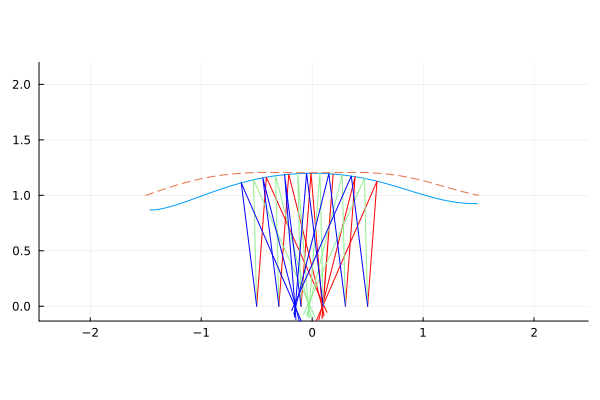

In [509]:
points = bezier(control, 0.)
points0 = bezier(control0, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
    points0 = hcat( points0, bezier(control0,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( - maximum( -1. .*points[2,:] ) -1. , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Mirror", dpi = 400)
plot!(points0[1,:],points0[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Initial mirror", linestyle=:dash, )
for (k,angle) in enumerate(angles)
    if k%2 == 0
        source4plot = (Ray([-0.5 + i / 5, 0.], angle  ) for i in 0:5)  
        for ray in source4plot
            plot!(ray,colors[k-1])
        end
    end
end
savefig("final_rays_focal.png")
display(plt)

Position des rayons sur le plan focal en fonction de l'angle d'entrée

In [505]:
collect(angles)

7-element Vector{Float64}:
 1.4461299516524444
 1.4959965017094252
 1.545863051766406
 1.5957296018233869
 1.645596151880368
 1.6954627019373487
 1.7453292519943295

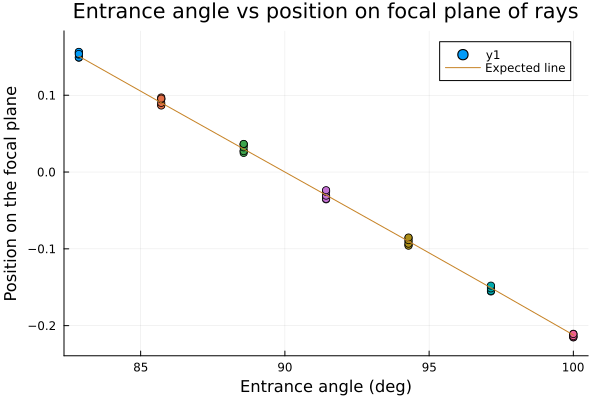

In [511]:
Nrayplot = 10
N = length(angles)
for (k,angle) in enumerate(angles)
    if k == 1
        plt = scatter( 180 .* angle * ones(N) ./ pi, collect( projectionplanfocal(billiard(control,Ray([-0.5 + k / Nrayplot, 0.], angle  )) ).pos[1] for k in 1:Nrayplot), xlabel = "Entrance angle (deg)", ylabel = "Position on the focal plane",  title = "Entrance angle vs position on focal plane of rays")
    else
        scatter!( 180 .* angle * ones(N) ./ pi, collect( projectionplanfocal(billiard(control,Ray([-0.5 + k / Nrayplot, 0.], angle  )) ).pos[1] for k in 1:Nrayplot), label = false)
    end
end
plot!( 180 .* angles ./ pi, focal .* cot.(angles) , label = "Expected line" )
savefig("dispersion_points_focal.png")
display(plt)